# Практическое задание №1
## Основы цифровой обработки сигналов: дискретизация, спектральный анализ, алиасинг

**Цель работы:**  
- Освоить базовые приёмы работы с библиотеками NumPy и Matplotlib в Jupyter Notebook.  
- Научиться генерировать различные типы сигналов и анализировать их спектры с помощью быстрого преобразования Фурье (БПФ).  
- Изучить эффект алиасинга и научиться правильно выбирать частоту дискретизации.  

**Необходимое ПО:**  
- Python 3 с установленными пакетами `numpy`, `matplotlib`, `scipy`, `ipywidgets` (для интерактива).  
- Jupyter Notebook / Google Colab.  

**Формат сдачи:**  
- Один Jupyter Notebook с выполненными заданиями, содержащий код, графики и текстовые ответы на вопросы.  
- Имя файла: `1_Фамилия.ipynb`.

## Часть 1. Знакомство с инструментарием

### 1.1. Импорт библиотек и создание временной оси

Выполните в первой ячейке:

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal
import ipywidgets as widgets
from IPython.display import display

%matplotlib inline
plt.rcParams['figure.figsize'] = (12, 5)

Создайте временную ось для сигнала длительностью 1 секунду с частотой дискретизации 1000 Гц (т.е. 1000 отсчётов в секунду). Выведите длину массива времени и шаг дискретизации.

In [2]:
fs = 1000          # частота дискретизации, Гц
T = 1              # длительность сигнала, с
t = np.linspace(0, T, int(fs * T), endpoint=False)  # временная ось

Ts = 1 / fs
print(f"Длина массива времени: {len(t)} отсчётов")
print(f"Шаг дискретизации (период): {Ts} с")

Длина массива времени: 1000 отсчётов
Шаг дискретизации (период): 0.001 с


**Вопрос 1:** Чему равен период дискретизации $T_s$? Как связаны частота дискретизации $f_s$ и период $T_s$?

Период дискретизации равен 0.001 с. Частота и период связаны Ts = 1 / fs

### 1.2. Генерация простых сигналов

Сгенерируйте и визуализируйте:
- Синусоидальный сигнал частотой 5 Гц, амплитудой 1.
- Сумму двух синусоид с частотами 5 и 12 Гц и одинаковыми амплитудами.
- Прямоугольный меандр частотой 2 Гц (используйте `signal.square`).

Для каждого сигнала постройте график временной зависимости (первые 0.5 секунды).

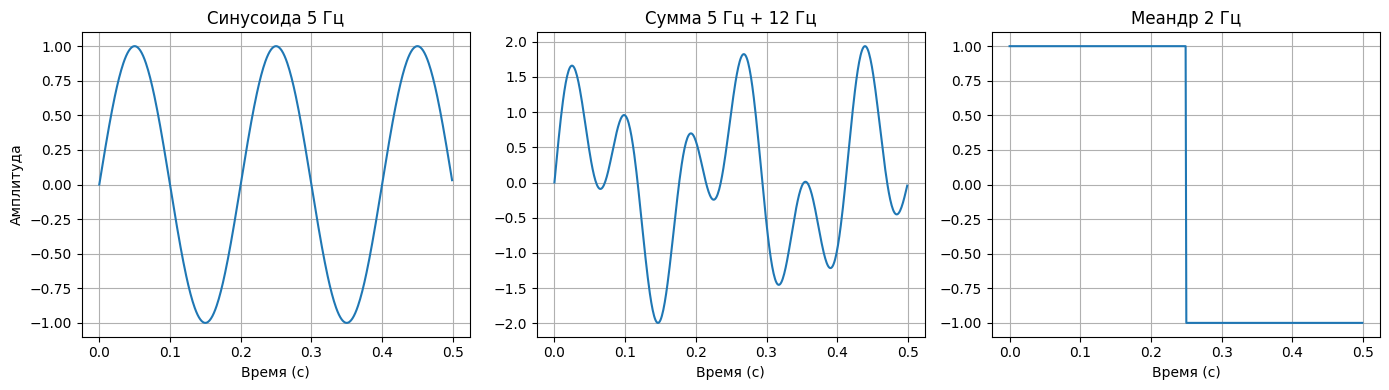

In [3]:
# Синусоида 5 Гц
f1 = 5
sin5 = np.sin(2 * np.pi * f1 * t)

# Сумма синусоид 5 и 12 Гц
f2 = 12
sum_sin = np.sin(2 * np.pi * f1 * t) + np.sin(2 * np.pi * f2 * t)

# Меандр 2 Гц
f3 = 2
meander = signal.square(2 * np.pi * f3 * t)

mask = t < 0.5

# Визуализация
plt.figure(figsize=(14, 4))

plt.subplot(1, 3, 1)
plt.plot(t[mask], sin5[mask])  # первые 0.5 с
plt.title('Синусоида 5 Гц')
plt.xlabel('Время (с)')
plt.ylabel('Амплитуда')
plt.grid(True)

plt.subplot(1, 3, 2)
plt.plot(t[mask], sum_sin[mask])
plt.title('Сумма 5 Гц + 12 Гц')
plt.xlabel('Время (с)')
plt.grid(True)

plt.subplot(1, 3, 3)
plt.plot(t[mask], meander[mask])
plt.title('Меандр 2 Гц')
plt.xlabel('Время (с)')
plt.grid(True)

plt.tight_layout()
plt.show()

**Вопрос 2:** Изменится ли вид суммы синусоид, если одну из них сдвинуть по фазе на 90° ($\pi/2$), на 180° ($\pi$), на 360° ($2\pi$)? (Проверьте на практике, изменив фазу второго сигнала). Объясните результат.

Вид суммы синусоид изменяется, если одну из них сдвинуть по фазе на pi/2 и pi, и не изменяется, если сдвинуть на 2pi. Это происходит, поскольку сдвиг на 2pi возвращает сигнал к исходному виду

## Часть 2. Спектральный анализ с помощью БПФ

### 2.1. Спектр синусоиды

Для синусоиды частотой 5 Гц вычислите БПФ (`np.fft.fft`). Постройте амплитудный спектр (модуль БПФ) для положительных частот. Не забудьте правильно нормировать амплитуды (поделить на количество отсчётов и учесть, что мы берём половину спектра). Частотную ось получите с помощью `np.fft.fftfreq`.

Подпишите оси: частота (Гц), амплитуда.

Максимум спектра: 5.0 Гц, амплитуда 1.000


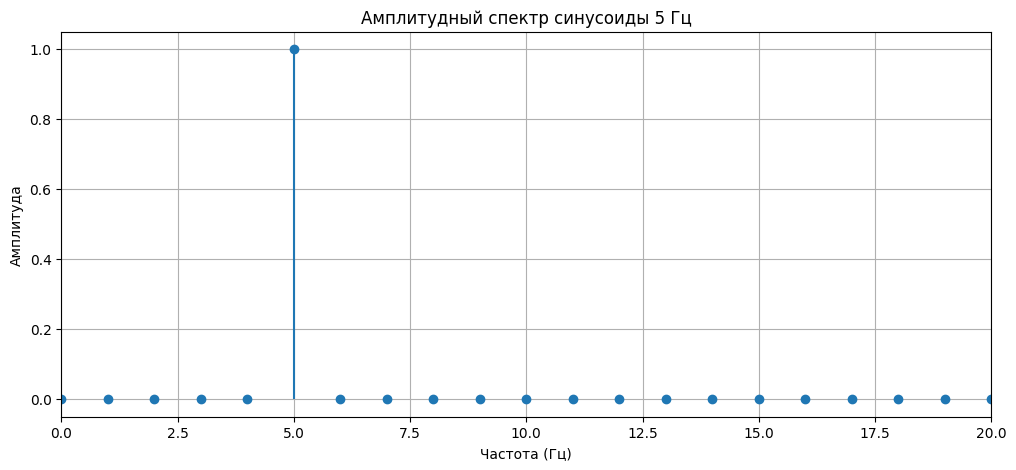

In [4]:
# БПФ синусоиды 5 Гц
N = len(sin5)
X = np.fft.fft(sin5)
freq = np.fft.fftfreq(N, d=1 / fs)

# Берём только положительные частоты
half = N // 2
X_mag = np.abs(X[:half]) / half  # не забываем про нормировку амплитуды
freq_pos = freq[:half]  # только положительные частоты

peak_index = np.argmax(X_mag)
print(f"Максимум спектра: {freq_pos[peak_index]:.1f} Гц, амплитуда {X_mag[peak_index]:.3f}")

plt.figure()
plt.stem(freq_pos, X_mag, basefmt=" ")
plt.title('Амплитудный спектр синусоиды 5 Гц')
plt.xlabel('Частота (Гц)')
plt.ylabel('Амплитуда')
plt.xlim(0, 20)
plt.grid(True)
plt.show()

**Вопрос 3:** Почему в спектре присутствует только один пик? Какая должна быть его амплитуда теоретически? Совпадает ли с полученной?

В спектре присутствует только один пик, поскольку синусоида имеет только 1 частотную составляющую. Его теоретическая амплитуда должна быть равна 1. Она совпадает с полученной, поскольку при нормировке БПФ амплитуда восстанавливается.

### 2.2. Спектр суммы синусоид

Для суммы синусоид (5 и 12 Гц) постройте амплитудный спектр. Убедитесь, что видны два пика на ожидаемых частотах. Измерьте их амплитуды.

Амплитуда на 5 Гц: 1.000
Амплитуда на 12 Гц: 1.000


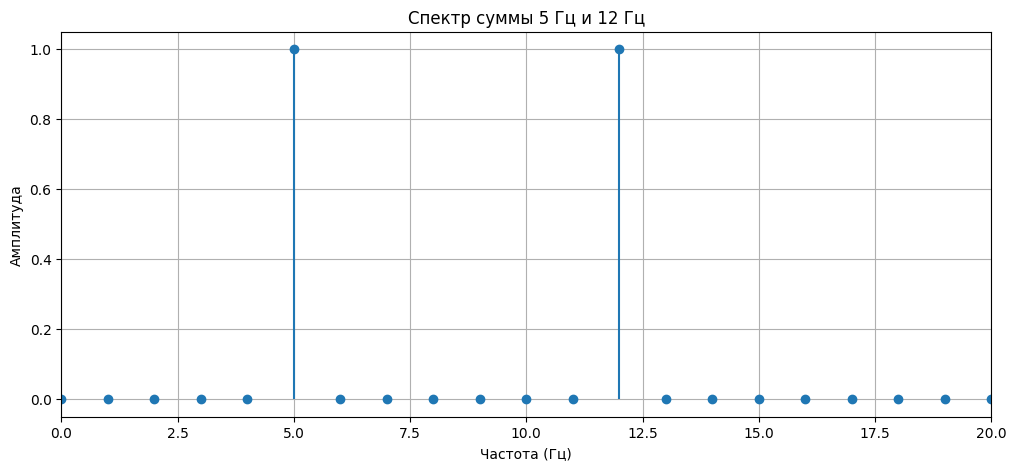

In [5]:
X_sum = np.fft.fft(sum_sin)
half_sum = len(sum_sin) // 2
freq_sum = np.fft.fftfreq(len(sum_sin), d=1 / fs)[:half_sum]
X_sum_mag = np.abs(X_sum[:half_sum]) / half_sum

idx_f1 = np.argmin(np.abs(freq_sum - f1))
idx_f2 = np.argmin(np.abs(freq_sum - f2))
print(f"Амплитуда на {f1} Гц: {X_sum_mag[idx_f1]:.3f}")
print(f"Амплитуда на {f2} Гц: {X_sum_mag[idx_f2]:.3f}")

plt.figure()
plt.stem(freq_sum, X_sum_mag, basefmt=" ")
plt.title('Спектр суммы 5 Гц и 12 Гц')
plt.xlabel('Частота (Гц)')
plt.ylabel('Амплитуда')
plt.xlim(0, 20)
plt.grid(True)
plt.show()

**Вопрос 4:** Изменится ли амплитудный спектр, если фазы сигналов изменить? Проверьте, задав для одного из них случайную фазу.

Если изменить фазы сигналов, то амплитудный спектр не изменится.

### 2.3. Спектр меандра

Постройте амплитудный спектр меандра частотой 2 Гц. Сравните с теоретическим представлением: меандр состоит из нечётных гармоник с убывающими амплитудами $(1, 1/3, 1/5,\dots)\cdot 4/\pi$.

Первые нечётные гармоники:
2 Гц: теория 1.273, БПФ 1.273
6 Гц: теория 0.424, БПФ 0.424
10 Гц: теория 0.255, БПФ 0.255
14 Гц: теория 0.182, БПФ 0.182
18 Гц: теория 0.141, БПФ 0.142


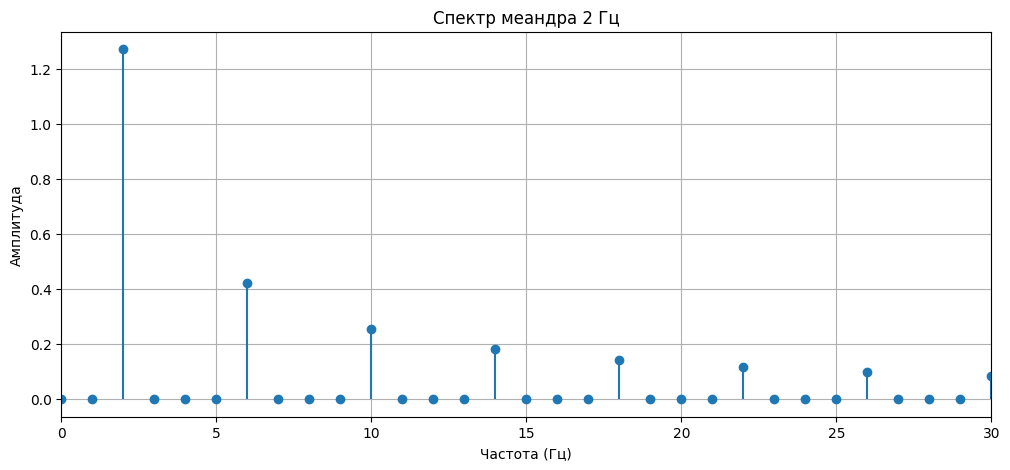

In [6]:
X_meander = np.fft.fft(meander)
half_meander = len(meander) // 2
freq_meander = np.fft.fftfreq(len(meander), d=1 / fs)[:half_meander]
X_meander_mag = np.abs(X_meander[:half_meander]) / half_meander

odd_numbers = np.array([1, 3, 5, 7, 9])
harmonics = f3 * odd_numbers
theoretical = 4 / (np.pi * odd_numbers)
measured = []

for harmonic in harmonics:
    idx = np.argmin(np.abs(freq_meander - harmonic))
    measured.append(X_meander_mag[idx])

print('Первые нечётные гармоники:')
for harmonic, amp_theory, amp_measured in zip(harmonics, theoretical, measured):
    print(f"{harmonic} Гц: теория {amp_theory:.3f}, БПФ {amp_measured:.3f}")

plt.figure()
plt.stem(freq_meander, X_meander_mag, basefmt=" ")
plt.title('Спектр меандра 2 Гц')
plt.xlabel('Частота (Гц)')
plt.ylabel('Амплитуда')
plt.xlim(0, 30)
plt.grid(True)
plt.show()


**Вопрос 5:** Почему в спектре меандра присутствуют только нечётные гармоники? Покажите, что амплитуды гармоник совпадают с теоретическим значением.

В спектре присутствуют только нечётные гармоники, поскольку симметричный меандр обладает симметрией, и четкие гармоники взаимоуничтожаются

Вычислим теоретические амплитуды нескольких первых гармоник: 2 гц - 4/pi ~ 1.273; 6гц - 4/3pi ~ 0.424; 10нц - 4/5pi ~ 0.255;
14гц - 4/7pi ~ 0.182; 18гц - 4/9pi ~ 0.141

При численном вычислении Фурье-преобразования получились следующие значения амплитуд гармоник: 2гц - 1.273; 6гц - 0.424; 10гц - 0.182; 18 гц - 0.141

Видим, что результаты вычислений совпадают с теоретическими значениями.

## Часть 3. Дискретизация и алиасинг

### 3.1. Корректная и некорректная дискретизация

Создайте «аналоговый» сигнал — синусоиду частотой 8 Гц, но с очень высокой частотой дискретизации (например, 1000 Гц), чтобы он выглядел гладким.

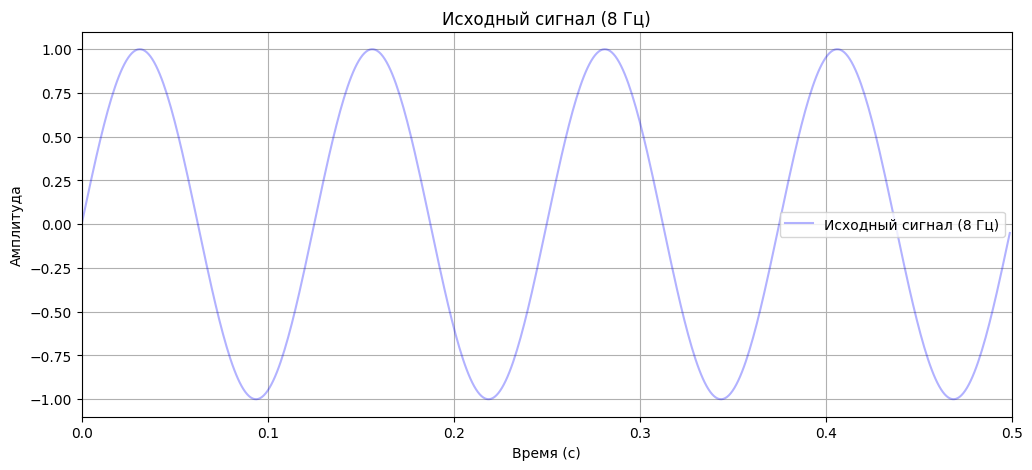

In [7]:
# «Аналоговый» сигнал с высокой частотой дискретизации
fs_analog = 1000
t_analog = np.linspace(0, T, int(fs_analog * T), endpoint=False)
f_signal = 8
analog_signal = np.sin(2 * np.pi * f_signal * t_analog)

mask_analog = t_analog < 0.5

plt.figure(figsize=(12,5))
plt.plot(t_analog[mask_analog], analog_signal[mask_analog], 'b-', alpha=0.3, label='Исходный сигнал (8 Гц)')
plt.xlabel('Время (с)')
plt.ylabel('Амплитуда')
plt.title('Исходный сигнал (8 Гц)')
plt.legend()
plt.grid(True)
plt.xlim(0, 0.5)
plt.show()

Теперь выполните его дискретизацию с двумя разными частотами:
- $f_{s1} = 50$ Гц (заведомо больше удвоенной частоты сигнала, 2·8=16 Гц);
- $f_{s2} = 12$ Гц (меньше 16 Гц).

Для этого создайте новые временные оси с шагом $1/f_{s1}$ и $1/f_{s2}$ и вычислите значения синусоиды в этих точках.

На одном графике изобразите:
- исходный гладкий сигнал (тонкая линия);
- отсчёты при корректной дискретизации (маркеры);
- отсчёты при алиасинге (маркеры другого цвета).

Также постройте сигнал, который «воспринимается» после дискретизации с малой частотой.

Алиас-частота для fs=12 Гц: 4.0 Гц


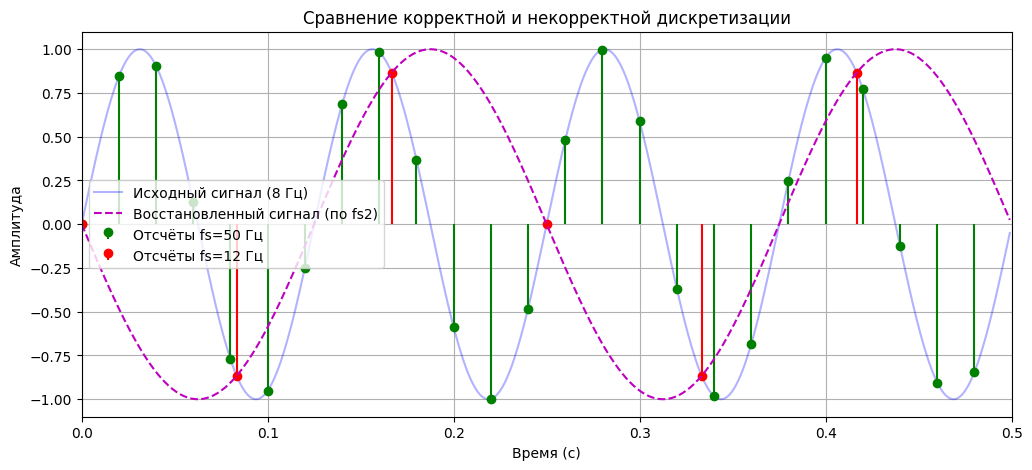

In [8]:
# Частоты дискретизации для эксперимента
fs1 = 50
fs2 = 12

# Отсчёты при корректной дискретизации
t1 = np.arange(0, T, 1 / fs1)
samples1 = np.sin(2 * np.pi * f_signal * t1)

# Отсчёты при некорректной дискретизации (алиасинг)
t2 = np.arange(0, T, 1 / fs2)
samples2 = np.sin(2 * np.pi * f_signal * t2)

f_alias_signed = ((f_signal + fs2 / 2) % fs2) - fs2 / 2
reconstructed_signal = np.sin(2 * np.pi * f_alias_signed * t_analog)

mask1 = t1 < 0.5
mask2 = t2 < 0.5

print(f"Алиас-частота для fs={fs2} Гц: {abs(f_alias_signed):.1f} Гц")

plt.figure(figsize=(12,5))
plt.plot(t_analog[mask_analog], analog_signal[mask_analog], 'b-', alpha=0.3, label='Исходный сигнал (8 Гц)')
plt.stem(t1[mask1], samples1[mask1], linefmt='g-', markerfmt='go', basefmt=' ', label=f'Отсчёты fs={fs1} Гц')
plt.stem(t2[mask2], samples2[mask2], linefmt='r-', markerfmt='ro', basefmt=' ', label=f'Отсчёты fs={fs2} Гц')
plt.plot(t_analog[mask_analog], reconstructed_signal[mask_analog], 'm--', label='Восстановленный сигнал (по fs2)')
plt.xlabel('Время (с)')
plt.ylabel('Амплитуда')
plt.title('Сравнение корректной и некорректной дискретизации')
plt.legend()
plt.grid(True)
plt.xlim(0, 0.5)
plt.show()

**Вопрос 6:** Какая частота «кажется» присутствующей в сигнале при $f_{s2}=12$ Гц? Совпадает ли она с предсказанной теоретически? (Подсказка: формула алиасинга $f_{alias} = |f - k f_s|$, выберите $k$ так, чтобы $f_{alias}$ лежала в интервале $[0, f_s/2]$.)

В сигнале при $f_{s2}=12$ Гц кажется, что присутствует частота 4гц. Она совпадает с теоретической: $f_{alias} = |f - k f_s| = |- 1 * 12| = 4гц при k=1

### 3.2. Интерактивная демонстрация алиасинга

Используя `ipywidgets.interact`, создайте интерактивный график, где можно менять частоту сигнала и частоту дискретизации ползунками, и сразу видеть исходный сигнал, отсчёты и восстановленный сигнал. Пример такого кода был на лекции.

Добейтесь, чтобы при нарушении условия Найквиста явно проявлялся алиасинг (восстановленный сигнал имел более низкую частоту, чем исходный).

In [9]:
def plot_aliasing(f_signal, f_sampling):
    t_cont = np.linspace(0, 0.5, 1000, endpoint=False)
    original_signal = np.sin(2 * np.pi * f_signal * t_cont)

    t_samples = np.arange(0, 0.5, 1 / f_sampling)
    sampled_signal = np.sin(2 * np.pi * f_signal * t_samples)

    f_alias_signed = ((f_signal + f_sampling / 2) % f_sampling) - f_sampling / 2
    reconstructed_signal = np.sin(2 * np.pi * f_alias_signed * t_cont)

    plt.figure(figsize=(12,4))
    plt.plot(t_cont, original_signal, 'b-', alpha=0.3, label='Исходный сигнал')
    plt.stem(t_samples, sampled_signal, linefmt='r-', markerfmt='ro', basefmt=' ', label='Отсчёты')
    plt.plot(t_cont, reconstructed_signal, 'm--', label=f'Восстановленный сигнал ({abs(f_alias_signed):.1f} Гц)')
    plt.xlabel('Время (с)')
    plt.ylabel('Амплитуда')
    plt.title(f'Частота сигнала = {f_signal:.1f} Гц, fs = {f_sampling:.1f} Гц')
    plt.legend()
    plt.grid(True)
    plt.xlim(0, 0.5)
    plt.show()

widgets.interact(
    plot_aliasing,
    f_signal=widgets.FloatSlider(min=1, max=20, step=1, value=8),
    f_sampling=widgets.FloatSlider(min=4, max=40, step=1, value=12),
);

interactive(children=(FloatSlider(value=8.0, description='f_signal', max=20.0, min=1.0, step=1.0), FloatSlider…

**Вопрос 7:** При каких соотношениях частоты сигнала и частоты дискретизации алиасинг наиболее заметен? Что происходит, когда частота сигнала в точности равна половине частоты дискретизации?

Алиасинг наиболее заметен, когда частота сигнала превышает половину частоты дискретизации.

Когда частота сигнала в точности равна половине частоты дискретизации, то неоднозначно.